## Inventory Optimization

Translate forecast variability and regional lead times into safety stock, reorder points, target inventory, and service KPIs.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
inventory_policy = pd.read_csv(PROJECT_ROOT / "data/processed/inventory_policy.csv")
inventory_kpis = pd.read_csv(PROJECT_ROOT / "data/processed/inventory_kpis.csv")
display(inventory_policy.head(20))
display(inventory_kpis.head(20))

,sku,region,average_daily_demand,demand_std,actual_average_demand,lead_time_days,lead_time_demand,safety_stock,reorder_point,target_inventory,days_of_inventory
0,BB1000,Central,506.689908,56.189684,509.717391,8,4053.519261,261.0,4315.0,7861.0,15.5
1,BB1000,East,528.995252,58.630197,536.353261,6,3173.971511,236.0,3410.0,7113.0,13.4
2,BB1000,North,572.505984,64.534266,571.130435,7,4007.541889,281.0,4289.0,8296.0,14.5
3,BB1000,South,615.923583,63.990016,625.836957,10,6159.235834,333.0,6492.0,10804.0,17.5
4,BB1000,West,644.630565,80.258733,651.461957,9,5801.675086,396.0,6198.0,10710.0,16.6
5,BB250,Central,574.076097,67.581361,577.320652,8,4592.608773,314.0,4907.0,8925.0,15.5
6,BB250,East,617.988295,70.511660,617.717391,6,3707.929773,284.0,3992.0,8318.0,13.5
7,BB250,North,624.273060,67.057372,632.739130,7,4369.911423,292.0,4662.0,9032.0,14.5
8,BB250,South,691.195554,79.402341,693.456522,10,6911.955536,413.0,7325.0,12163.0,17.6
9,BB250,West,733.017013,79.967597,738.842391,9,6597.153113,395.0,6992.0,12123.0,16.5


,sku,region,total_demand,fulfilled_demand,lost_sales,average_inventory,max_inventory,stockout_days,replenishment_orders,service_level,stockout_rate,average_inventory_value,annual_demand_value,inventory_turns,annual_holding_cost
0,BB1000,Central,93788.0,93699.0,89.0,2317.429348,7332.0,1,24,99.91,0.09,127458.61,10232576.63,80.28,25491.72
1,BB1000,East,98689.0,98580.0,109.0,2315.929348,6579.0,1,24,99.89,0.11,127376.11,10767291.71,84.53,25475.22
2,BB1000,North,105088.0,105088.0,0.0,2584.065217,7653.0,0,24,100.00,0.00,142123.59,11465443.48,80.67,28424.72
3,BB1000,South,115154.0,114813.0,341.0,2823.956522,10029.0,1,24,99.70,0.30,155317.61,12563676.90,80.89,31063.52
4,BB1000,West,119869.0,119596.0,273.0,2970.630435,10070.0,2,24,99.77,0.23,163384.67,13078098.78,80.04,32676.93
5,BB250,Central,106227.0,106044.0,183.0,2607.461957,8414.0,2,24,99.83,0.17,62579.09,5057328.91,80.81,12515.82
6,BB250,East,113660.0,113638.0,22.0,2721.076087,7649.0,1,24,99.98,0.02,65305.83,5411204.35,82.86,13061.17
7,BB250,North,116424.0,115918.0,506.0,2731.461957,8430.0,3,24,99.57,0.43,65555.09,5542794.78,84.55,13111.02
8,BB250,South,127596.0,127596.0,0.0,3279.086957,11518.0,0,24,100.00,0.00,78698.09,6074679.13,77.19,15739.62
9,BB250,West,135947.0,135711.0,236.0,3415.478261,11385.0,2,24,99.83,0.17,81971.48,6472259.35,78.96,16394.30


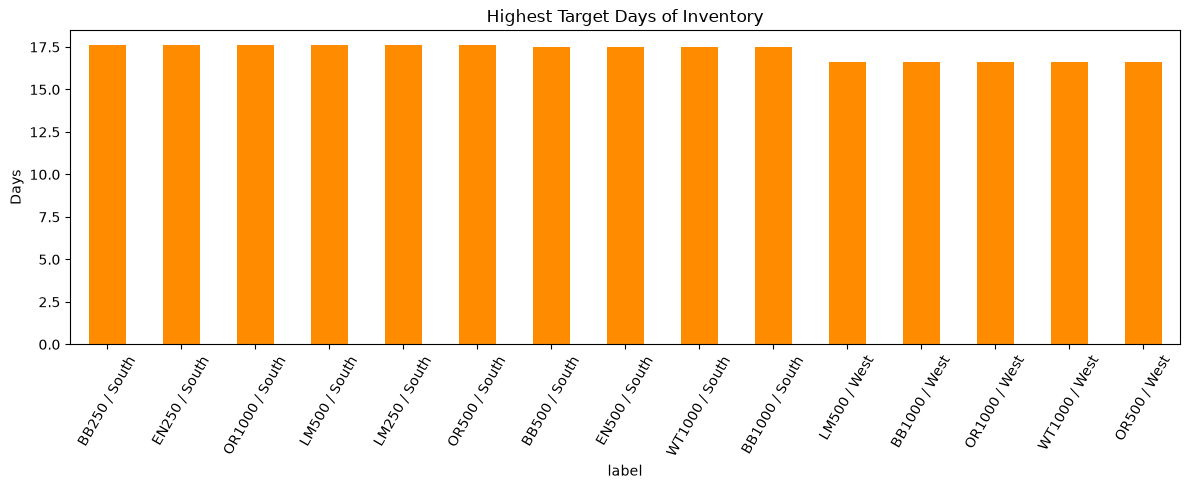

In [4]:
high_inventory = inventory_policy.sort_values("days_of_inventory", ascending=False).head(15)
plt.figure(figsize=(12, 5))
high_inventory.assign(label=lambda x: x["sku"] + " / " + x["region"]).plot.bar(x="label", y="days_of_inventory", legend=False, ax=plt.gca(), color="darkorange")
plt.title("Highest Target Days of Inventory")
plt.ylabel("Days")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

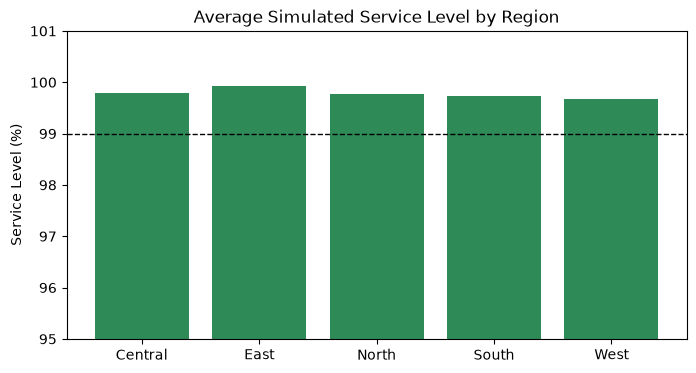

In [5]:
service_by_region = inventory_kpis.groupby("region", as_index=False)["service_level"].mean()
plt.figure(figsize=(8, 4))
plt.bar(service_by_region["region"], service_by_region["service_level"], color="seagreen")
plt.axhline(99, color="black", linestyle="--", linewidth=1)
plt.title("Average Simulated Service Level by Region")
plt.ylabel("Service Level (%)")
plt.ylim(95, 101)
plt.show()

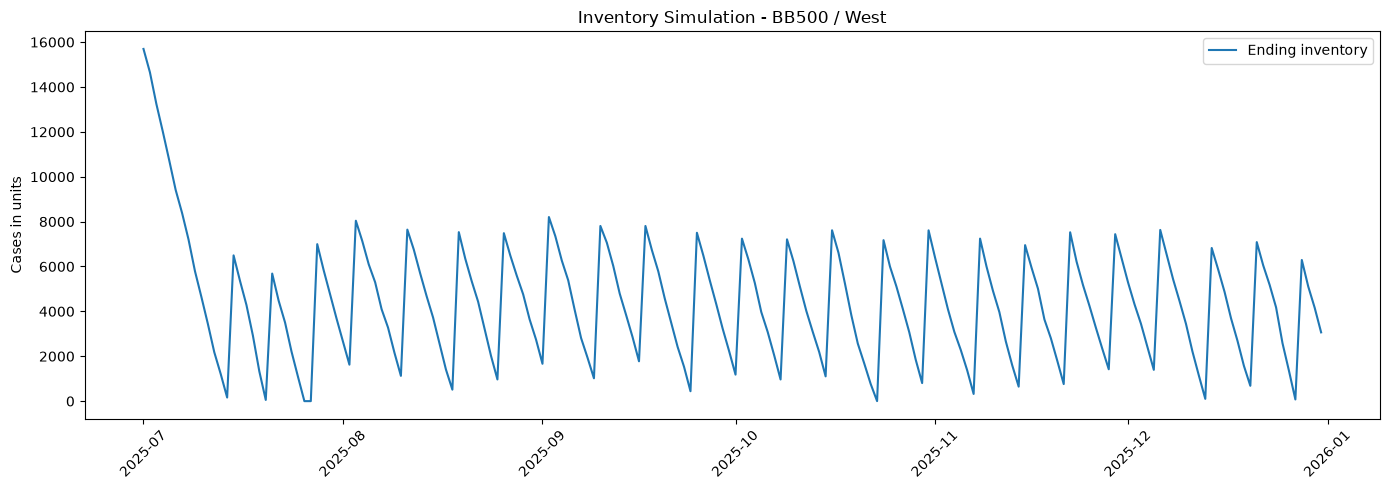

In [6]:
simulation = pd.read_csv(PROJECT_ROOT / "data/processed/inventory_simulation.csv", parse_dates=["date"])
sample = simulation[(simulation["sku"] == "BB500") & (simulation["region"] == "West")]
plt.figure(figsize=(14, 5))
plt.plot(sample["date"], sample["ending_inventory"], label="Ending inventory")
plt.title("Inventory Simulation - BB500 / West")
plt.ylabel("Cases in units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()